In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

pd.set_option('display.max_columns', None)
np.random.seed(42)

In [2]:
df = pd.read_csv('ecommerce_customer_data.csv')
df.columns = [c.strip() for c in df.columns]
print("Shape:", df.shape)
df.head()

Shape: (3900, 18)


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [3]:
print("Unique customers:", df['Customer ID'].nunique())
print("Unique items:", df['Item Purchased'].nunique())
print("Categories:", df['Category'].unique())
print("Review rating range:", df['Review Rating'].min(), "-", df['Review Rating'].max())

Unique customers: 3900
Unique items: 25
Categories: ['Clothing' 'Footwear' 'Outerwear' 'Accessories']
Review rating range: 2.5 - 5.0


In [4]:
all_items = df['Item Purchased'].unique().tolist()
item_category = df.drop_duplicates('Item Purchased').set_index('Item Purchased')['Category'].to_dict()

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
print("Train size:", train_df.shape[0])
print("Test size:", test_df.shape[0])

Train size: 3120
Test size: 780


In [5]:
item_stats = train_df.groupby('Item Purchased')['Review Rating'].agg(['mean', 'count']).reset_index()
item_stats.columns = ['Item Purchased', 'avg_rating', 'num_purchases']
C = item_stats['avg_rating'].mean()
m = item_stats['num_purchases'].quantile(0.5)
item_stats['pop_score'] = (
    (item_stats['num_purchases'] / (item_stats['num_purchases'] + m)) * item_stats['avg_rating']
    + (m / (item_stats['num_purchases'] + m)) * C
)
pop_score_map = item_stats.set_index('Item Purchased')['pop_score'].to_dict()
item_avg_rating = item_stats.set_index('Item Purchased')['avg_rating'].to_dict()

def popularity_score(customer_row, item):
    return pop_score_map.get(item, C)

item_stats.merge(pd.DataFrame(list(item_category.items()), columns=['Item Purchased','Category']), on='Item Purchased').sort_values('pop_score', ascending=False).head(10)

,Item Purchased,avg_rating,num_purchases,pop_score,Category
14,Sandals,3.864122,131,3.808163,Footwear
8,Hat,3.825424,118,3.786555,Accessories
6,Gloves,3.824779,113,3.785441,Accessories
1,Belt,3.796694,121,3.773008,Accessories
24,T-shirt,3.794783,115,3.771512,Clothing
3,Boots,3.786111,108,3.766834,Footwear
19,Skirt,3.780620,129,3.765648,Clothing
22,Sunglasses,3.773228,127,3.761834,Accessories
4,Coat,3.766154,130,3.758389,Outerwear
12,Jewelry,3.761538,143,3.756318,Accessories


In [6]:
def age_bucket(age):
    if age < 25: return '<25'
    if age < 35: return '25-34'
    if age < 45: return '35-44'
    if age < 55: return '45-54'
    return '55+'

train_df = train_df.copy()
train_df['age_bucket'] = train_df['Age'].apply(age_bucket)
test_df = test_df.copy()
test_df['age_bucket'] = test_df['Age'].apply(age_bucket)

group_cat_counts = train_df.groupby(['Gender', 'age_bucket', 'Category']).size().reset_index(name='n')
group_totals = train_df.groupby(['Gender', 'age_bucket']).size().reset_index(name='total')
group_cat = group_cat_counts.merge(group_totals, on=['Gender', 'age_bucket'])
group_cat['affinity'] = group_cat['n'] / group_cat['total']
affinity_map = {(r.Gender, r.age_bucket, r.Category): r.affinity for r in group_cat.itertuples()}

def content_based_score(customer_row, item):
    cat = item_category[item]
    key = (customer_row['Gender'], customer_row['age_bucket'], cat)
    affinity = affinity_map.get(key, 0.01)
    base_rating = item_avg_rating.get(item, C)
    return affinity * base_rating

group_cat.sort_values('affinity', ascending=False).head(10)

,Gender,age_bucket,Category,n,total,affinity
37,Male,<25,Clothing,134,269,0.498141
17,Female,<25,Clothing,63,131,0.480916
5,Female,35-44,Clothing,93,197,0.472081
33,Male,55+,Clothing,294,648,0.453704
9,Female,45-54,Clothing,95,210,0.452381
29,Male,45-54,Clothing,174,393,0.442748
21,Male,25-34,Clothing,175,396,0.441919
1,Female,25-34,Clothing,81,192,0.421875
25,Male,35-44,Clothing,164,394,0.416244
13,Female,55+,Clothing,118,290,0.406897


In [7]:
cust_features = ['Age', 'Gender', 'Location', 'Season', 'Subscription Status',
                  'Previous Purchases', 'Frequency of Purchases', 'Payment Method']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), ['Age', 'Previous Purchases']),
    ('cat', OneHotEncoder(handle_unknown='ignore'),
     ['Gender', 'Location', 'Season', 'Subscription Status', 'Frequency of Purchases', 'Payment Method']),
])

train_cust_matrix = preprocessor.fit_transform(train_df[cust_features])
knn = NearestNeighbors(n_neighbors=15, metric='cosine')
knn.fit(train_cust_matrix)

train_items_arr = train_df['Item Purchased'].values
train_ratings_arr = train_df['Review Rating'].values

def knn_scores_for_customer(customer_row):
    vec = preprocessor.transform(pd.DataFrame([customer_row[cust_features]]))
    dist, idx = knn.kneighbors(vec, n_neighbors=15)
    neighbor_items = train_items_arr[idx[0]]
    neighbor_ratings = train_ratings_arr[idx[0]]
    scores = {}
    for it, rt in zip(neighbor_items, neighbor_ratings):
        scores.setdefault(it, []).append(rt)
    return {it: np.mean(v) * len(v) for it, v in scores.items()}

In [8]:
reg_features = cust_features + ['Category']
reg_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), ['Age', 'Previous Purchases']),
    ('cat', OneHotEncoder(handle_unknown='ignore'),
     ['Gender', 'Location', 'Season', 'Subscription Status', 'Frequency of Purchases', 'Payment Method', 'Category']),
])
reg_pipeline = Pipeline([
    ('prep', reg_preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, random_state=42, max_depth=8)),
])
reg_pipeline.fit(train_df[reg_features], train_df['Review Rating'])

test_preds = reg_pipeline.predict(test_df[reg_features])
rmse_reg = np.sqrt(mean_squared_error(test_df['Review Rating'], test_preds))
print(f"Regression RMSE on actual test purchases: {rmse_reg:.4f}")

def regression_score(customer_row, item):
    row = customer_row[cust_features].to_dict()
    row['Category'] = item_category[item]
    x = pd.DataFrame([row])
    return reg_pipeline.predict(x)[0]

Regression RMSE on actual test purchases: 0.7405


In [9]:
def hit_rate_at_k(score_fn, k=5, n_negatives=9, use_cache=False):
    hits, total = 0, 0
    rng = np.random.RandomState(42)
    for _, row in test_df.iterrows():
        actual_item = row['Item Purchased']
        negatives = rng.choice([it for it in all_items if it != actual_item], size=n_negatives, replace=False)
        candidates = list(negatives) + [actual_item]
        rng.shuffle(candidates)
        if use_cache:
            cache = knn_scores_for_customer(row)
            scores = [(it, cache.get(it, 0.0) + rng.uniform(0, 1e-6)) for it in candidates]
        else:
            scores = [(it, score_fn(row, it) + rng.uniform(0, 1e-6)) for it in candidates]
        scores.sort(key=lambda x: x[1], reverse=True)
        top_k_items = [it for it, _ in scores[:k]]
        total += 1
        if actual_item in top_k_items:
            hits += 1
    return hits / total

hr_pop = hit_rate_at_k(popularity_score, k=5)
hr_content = hit_rate_at_k(content_based_score, k=5)
hr_knn = hit_rate_at_k(None, k=5, use_cache=True)
hr_reg = hit_rate_at_k(regression_score, k=5)

results_df = pd.DataFrame({
    'Algorithm': ['Popularity-Based', 'Content-Based (Demographic Affinity)',
                  'KNN Demographic CF', 'Regression-Based (Random Forest)'],
    'Hit Rate@5': [hr_pop, hr_content, hr_knn, hr_reg],
}).sort_values('Hit Rate@5', ascending=False)
results_df

,Algorithm,Hit Rate@5
1,Content-Based (Demographic Affinity),0.511538
0,Popularity-Based,0.505128
2,KNN Demographic CF,0.492308
3,Regression-Based (Random Forest),0.476923


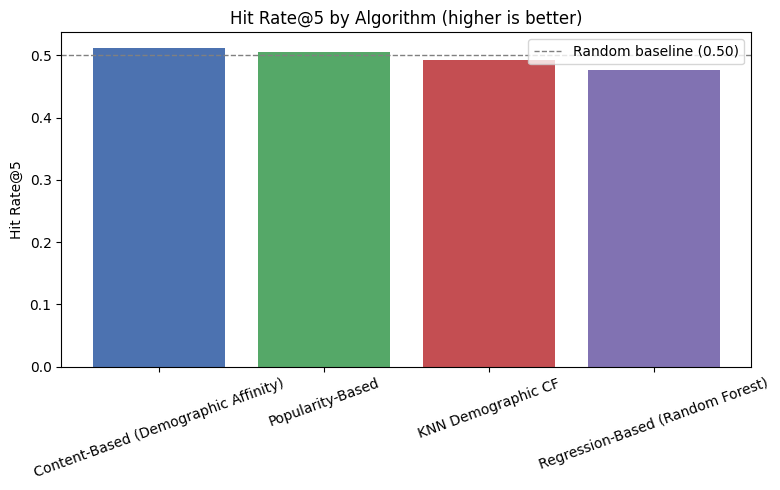

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
ax.bar(results_df['Algorithm'], results_df['Hit Rate@5'], color=colors)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Random baseline (0.50)')
ax.set_title('Hit Rate@5 by Algorithm (higher is better)')
ax.set_ylabel('Hit Rate@5')
ax.tick_params(axis='x', rotation=20)
ax.legend()
plt.tight_layout()
plt.savefig('algorithm_comparison.png', dpi=150)
plt.show()

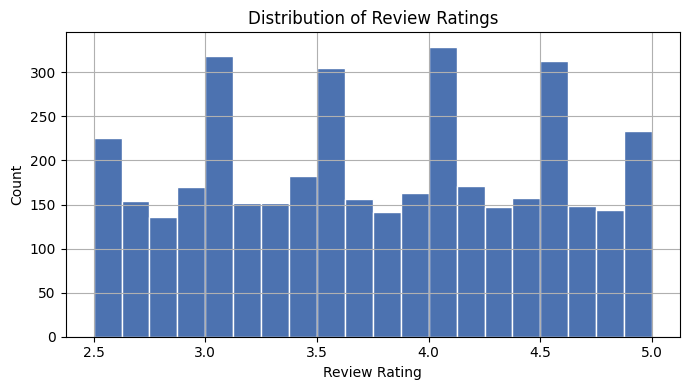

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
df['Review Rating'].hist(bins=20, ax=ax, color='#4C72B0', edgecolor='white')
ax.set_title('Distribution of Review Ratings')
ax.set_xlabel('Review Rating')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=150)
plt.show()

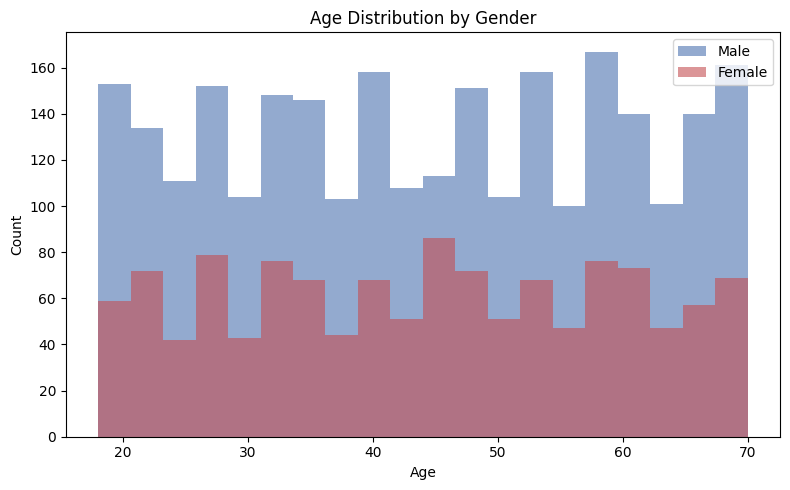

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
for gender, color in zip(df['Gender'].unique(), ['#4C72B0', '#C44E52']):
    subset = df[df['Gender'] == gender]
    ax.hist(subset['Age'], bins=20, alpha=0.6, label=gender, color=color)
ax.set_title('Age Distribution by Gender')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('age_distribution_by_gender.png', dpi=150)
plt.show()

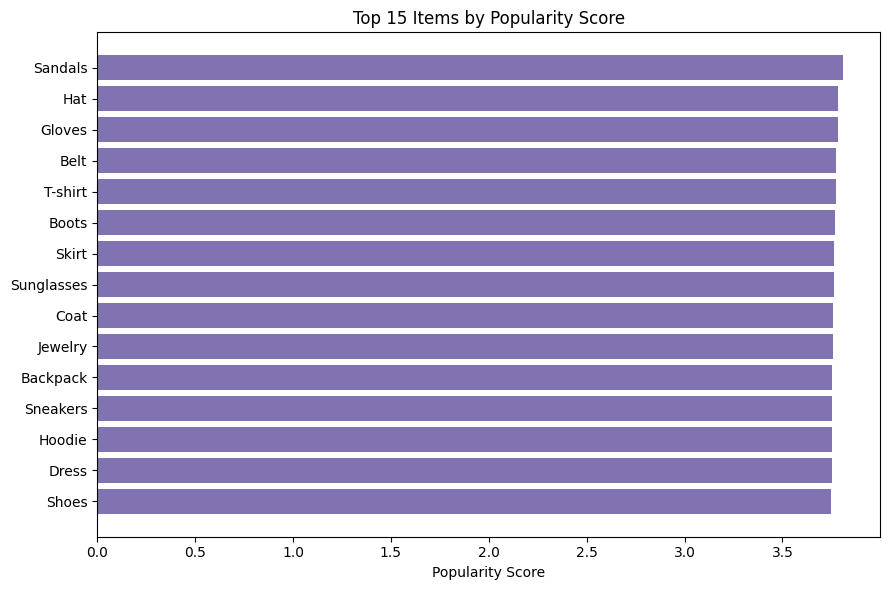

In [15]:
top15 = item_stats.sort_values('pop_score', ascending=False).head(15)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top15['Item Purchased'], top15['pop_score'], color='#8172B2')
ax.invert_yaxis()
ax.set_title('Top 15 Items by Popularity Score')
ax.set_xlabel('Popularity Score')
plt.tight_layout()
plt.savefig('top15_items_popularity.png', dpi=150)
plt.show()

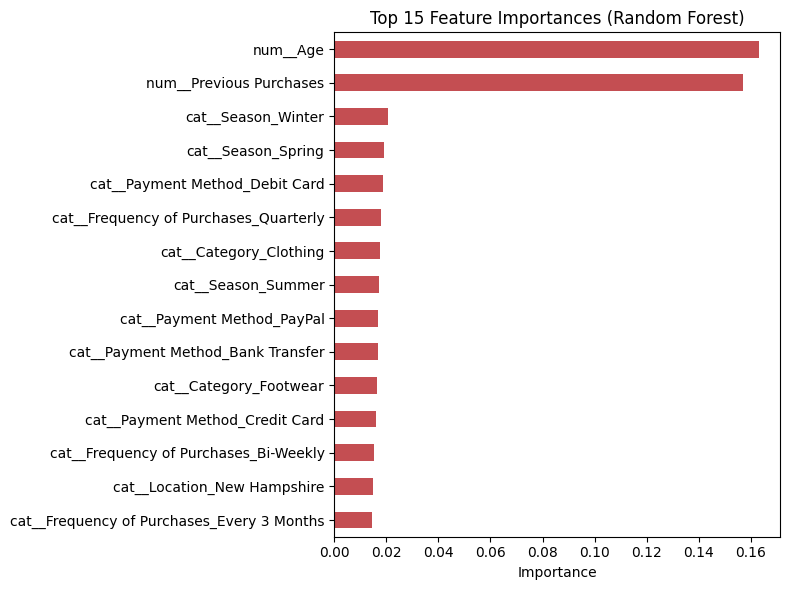

In [16]:
feat_names = reg_pipeline.named_steps['prep'].get_feature_names_out()
importances = reg_pipeline.named_steps['model'].feature_importances_
feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.plot(kind='barh', ax=ax, color='#C44E52')
ax.invert_yaxis()
ax.set_title('Top 15 Feature Importances (Random Forest)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

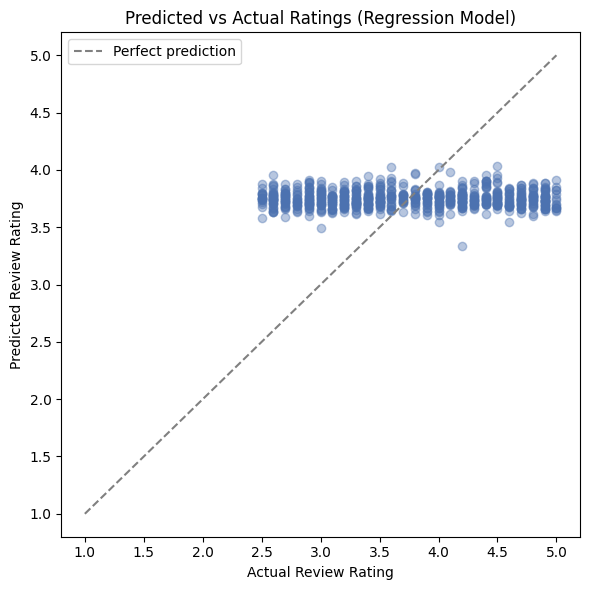

In [17]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(test_df['Review Rating'], test_preds, alpha=0.4, color='#4C72B0')
ax.plot([1, 5], [1, 5], color='gray', linestyle='--', label='Perfect prediction')
ax.set_xlabel('Actual Review Rating')
ax.set_ylabel('Predicted Review Rating')
ax.set_title('Predicted vs Actual Ratings (Regression Model)')
ax.legend()
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150)
plt.show()

/tmp/ipykernel_2379/1324891820.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=categories)


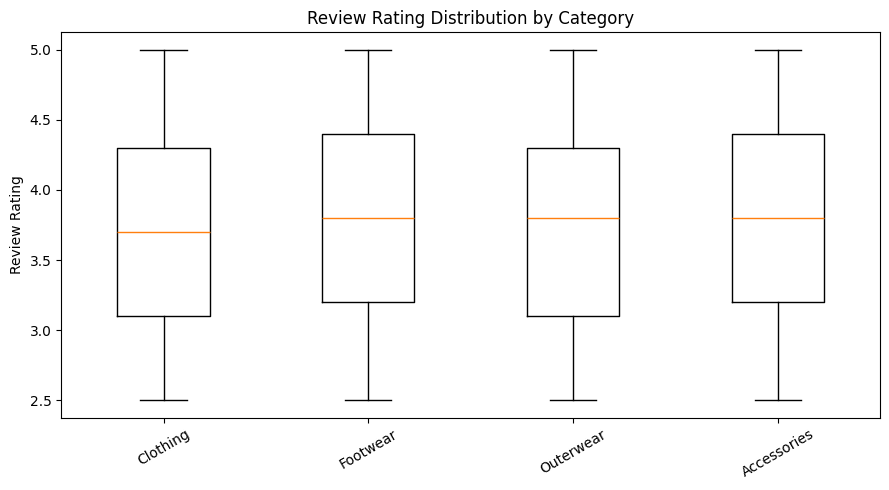

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
categories = df['Category'].unique()
data = [df[df['Category'] == c]['Review Rating'] for c in categories]
ax.boxplot(data, labels=categories)
ax.set_title('Review Rating Distribution by Category')
ax.set_ylabel('Review Rating')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('rating_boxplot_by_category.png', dpi=150)
plt.show()

In [12]:
sample_customer = test_df.iloc[0]
candidate_scores = [(it, regression_score(sample_customer, it)) for it in all_items]
candidate_scores.sort(key=lambda x: x[1], reverse=True)
top_5 = pd.DataFrame(candidate_scores[:5], columns=['Item Purchased', 'predicted_rating'])
top_5['Category'] = top_5['Item Purchased'].map(item_category)
print(f"Sample customer profile: Age {sample_customer['Age']}, {sample_customer['Gender']}, "
      f"{sample_customer['Location']}, actually bought '{sample_customer['Item Purchased']}'")
top_5

Sample customer profile: Age 48, Male, Illinois, actually bought 'Shirt'


,Item Purchased,predicted_rating,Category
0,Coat,3.698023,Outerwear
1,Jacket,3.698023,Outerwear
2,Sandals,3.678995,Footwear
3,Sneakers,3.678995,Footwear
4,Shoes,3.678995,Footwear
